# 💧 PRÉDICTION VAPORISATION EAU — HVAC
## Démarche Complète : Cours T. Masrour → Deep Learning → XGBoost

**Auteur :** Yasser Khadiri  
**Référence :** *Cours Séries Temporelles* — Pr. Tawfik Masrour (ENSAM-IATD, 2024-2025)  
**Fix :** ✅ Données castées en `float32` dès la source — aucun `tf.constant` nécessaire

---
```
PHASE 1 — PIPELINE CLASSIQUE (Cours Masrour)  : Étapes 1→7
PHASE 2 — DEEP LEARNING                       : ANN · LSTM · Bi-LSTM · GRU · CNN-LSTM · Attention-LSTM
PHASE 3 — XGBOOST                             : Feature Engineering + GridSearchCV
PHASE 4 — COMPARAISON FINALE
```


## 📦 Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D,
    Dropout, BatchNormalization, Flatten, Input,
    MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

plt.rcParams.update({'figure.dpi':110,'figure.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False})
sns.set_palette('tab10')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGET   = 'Eau_Vaporisee_g_par_heure'
EXOG     = ['Consommation_HVAC_kWh','Temperature_C','Humidite_Relative_%','CO2_ppm']
ALL_VARS = [TARGET] + EXOG
SEQ_LEN  = 24
BATCH    = 32
EPOCHS   = 150

RESULTS   = {}
PREDS     = {}
HISTORIES = {}

def store(name, y_true, y_pred, phase=''):
    y_pred = np.clip(np.array(y_pred, dtype=np.float64), 0, None)
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/(y_true + 1e-9))) * 100
    qual = ('✅ Excellent' if r2>=0.70 else '✓ Bon' if r2>=0.50
            else '⚠️ Acceptable' if r2>=0.30 else '❌ Faible')
    RESULTS[name] = {'Phase':phase,'R²':r2,'MAE':mae,'RMSE':rmse,'MAPE':mape,'Qualité':qual}
    PREDS[name]   = (y_true, y_pred)
    print(f'  {name:<32} R²={r2:.4f}  MAE={mae:.1f}  RMSE={rmse:.1f}  {qual}')
    return r2

gpus = tf.config.list_physical_devices('GPU')
print(f'✅ TensorFlow {tf.__version__} | GPU: {gpus[0].name if gpus else "CPU"}')
print(f'✅ XGBoost {xgb.__version__}')
print('✅ Tous les imports chargés')


✅ TensorFlow 2.20.0 | GPU: CPU
✅ XGBoost 3.2.0
✅ Tous les imports chargés


---
# 🎓 PHASE 1 — Pipeline Classique (Cours Pr. Masrour)


## 📈 Étape 1 — Chargement & Visualisation

In [2]:
df_raw = pd.read_excel('HVAC_Vaporisation_10jours_CLEAN.xlsx')
df_raw['Horodatage'] = pd.to_datetime(df_raw['Horodatage'])
df_raw.set_index('Horodatage', inplace=True)
df_raw.sort_index(inplace=True)
df = df_raw[ALL_VARS].resample('1h').mean().dropna()

print('═'*60)
print(f'  Forme    : {df.shape}')
print(f'  Période  : {df.index.min()} → {df.index.max()}')
print(f'  Fréquence: 1h (agrégation de 10 min)')
print(df[ALL_VARS].describe().round(2))


════════════════════════════════════════════════════════════
  Forme    : (1667, 5)
  Période  : 2017-01-01 00:00:00 → 2017-03-11 10:00:00
  Fréquence: 1h (agrégation de 10 min)
       Eau_Vaporisee_g_par_heure  Consommation_HVAC_kWh  Temperature_C  \
count                    1667.00                1667.00        1667.00   
mean                      317.75                   6.02          23.93   
std                        97.40                   0.94           1.36   
min                        92.02                   3.23          19.99   
25%                       245.55                   5.37          22.96   
50%                       308.61                   6.00          23.90   
75%                       373.88                   6.65          24.88   
max                       758.02                   9.01          27.65   

       Humidite_Relative_%  CO2_ppm  
count              1667.00  1667.00  
mean                 50.18   800.02  
std                   4.79    93.36  
min

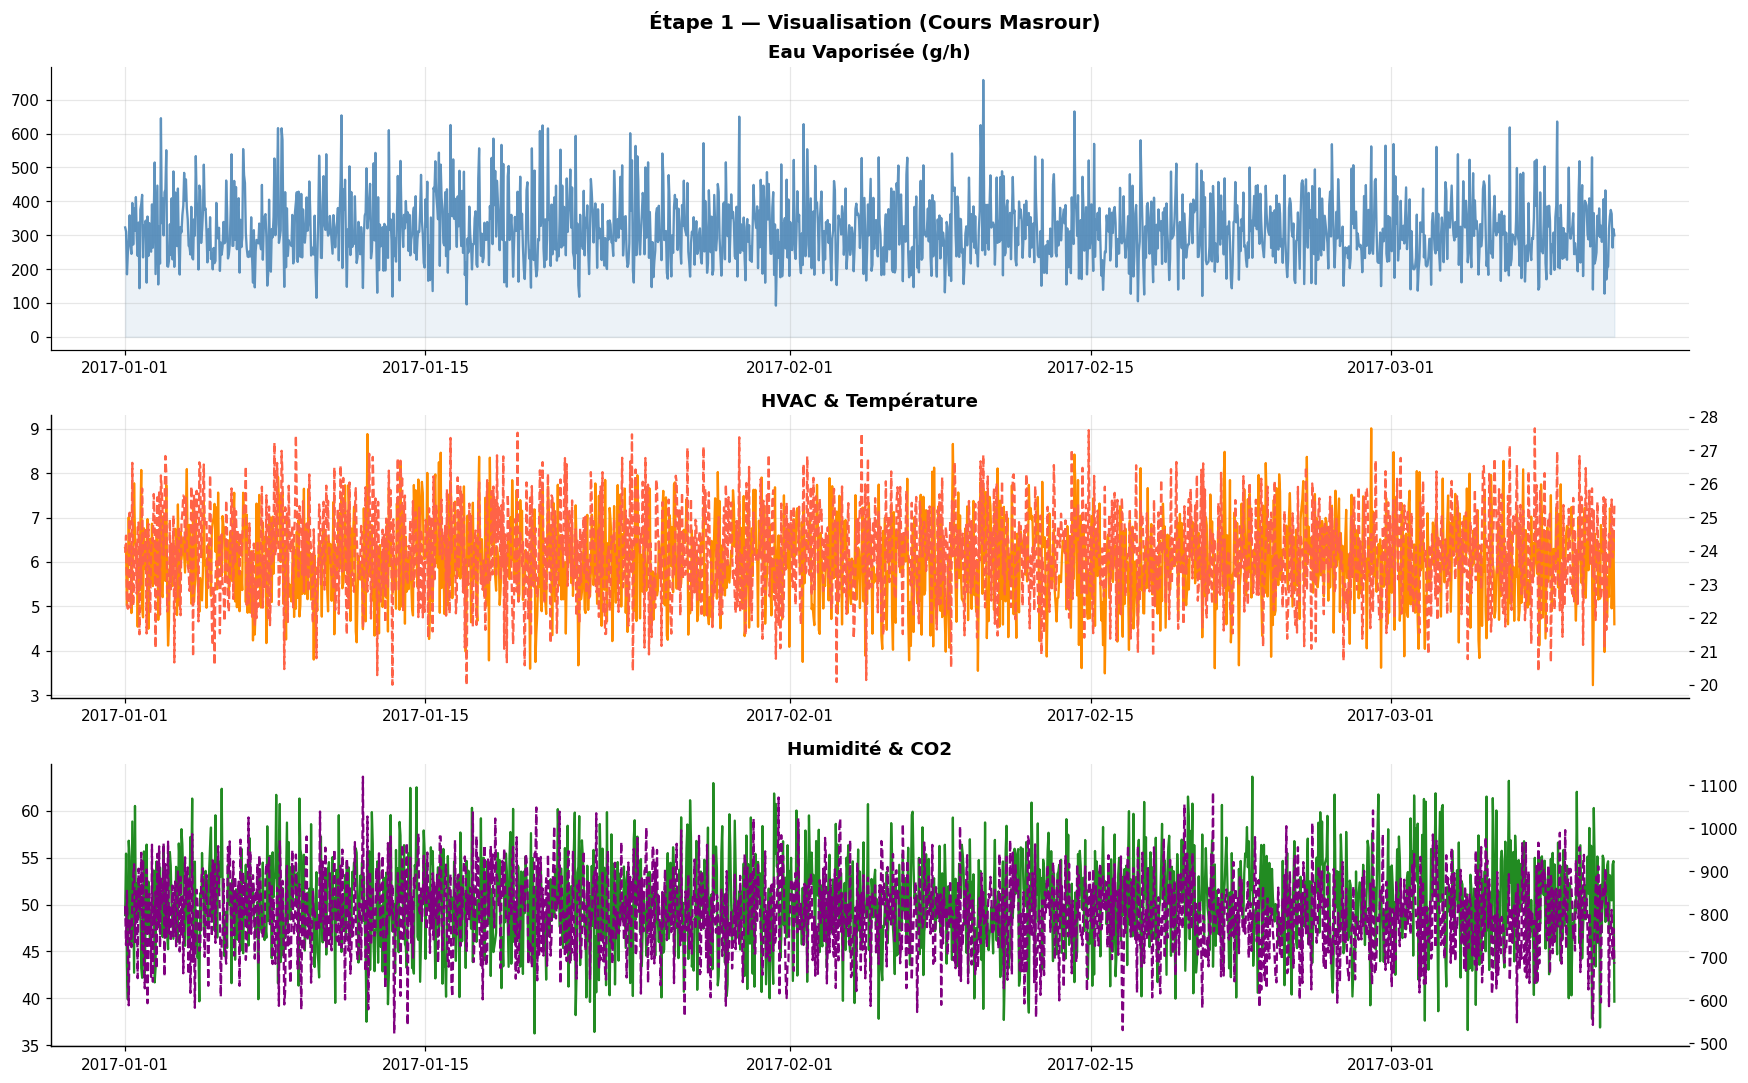

✅ Étape 1 — Visualisation complète


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
axes[0].plot(df[TARGET], color='steelblue', lw=1.5, alpha=0.85)
axes[0].fill_between(df.index, df[TARGET], alpha=0.1, color='steelblue')
axes[0].set_title('Eau Vaporisée (g/h)', fontweight='bold')
axes[0].grid(alpha=0.3)

ax2 = axes[1].twinx()
axes[1].plot(df['Consommation_HVAC_kWh'], color='darkorange', lw=1.5, label='HVAC (kWh)')
ax2.plot(df['Temperature_C'], color='tomato', lw=1.5, ls='--', label='Temp (°C)')
axes[1].set_title('HVAC & Température', fontweight='bold'); axes[1].grid(alpha=0.3)

ax4 = axes[2].twinx()
axes[2].plot(df['Humidite_Relative_%'], color='forestgreen', lw=1.5, label='Humidité (%)')
ax4.plot(df['CO2_ppm'], color='purple', lw=1.5, ls='--', label='CO2 (ppm)')
axes[2].set_title('Humidité & CO2', fontweight='bold'); axes[2].grid(alpha=0.3)

plt.suptitle('Étape 1 — Visualisation (Cours Masrour)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('etape1_visualisation.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Étape 1 — Visualisation complète')


## 📐 Étape 2 — Tests de Stationnarité (ADF · KPSS)

In [5]:
serie = df[TARGET].copy()

adf = adfuller(serie, autolag='AIC')
print('  ADF (Augmented Dickey-Fuller)')
print(f'    Statistique : {adf[0]:.4f}  |  p-value : {adf[1]:.6f}')
for k,v in adf[4].items(): print(f'    Val. critique {k}: {v:.4f}')
stationnaire_adf = adf[1] < 0.05
print(f'    → {"✅ STATIONNAIRE" if stationnaire_adf else "❌ NON-STATIONNAIRE"} (p {"<" if stationnaire_adf else ">"} 0.05)')

kp_stat, kp_p, _, _ = kpss(serie, regression='c', nlags='auto')
print(f'\n  KPSS')
print(f'    Statistique : {kp_stat:.4f}  |  p-value : {kp_p:.4f}')
stationnaire_kpss = kp_p > 0.05
print(f'    → {"✅ STATIONNAIRE" if stationnaire_kpss else "❌ NON-STATIONNAIRE"}')

d_order = 0 if stationnaire_adf else 1
print(f'\n  Ordre de différenciation retenu : d = {d_order}')


  ADF (Augmented Dickey-Fuller)
    Statistique : -40.8904  |  p-value : 0.000000
    Val. critique 1%: -3.4343
    Val. critique 5%: -2.8633
    Val. critique 10%: -2.5677
    → ✅ STATIONNAIRE (p < 0.05)

  KPSS
    Statistique : 0.5494  |  p-value : 0.0306
    → ❌ NON-STATIONNAIRE

  Ordre de différenciation retenu : d = 0


## 🔄 Étape 3 — Transformation & Décomposition STL

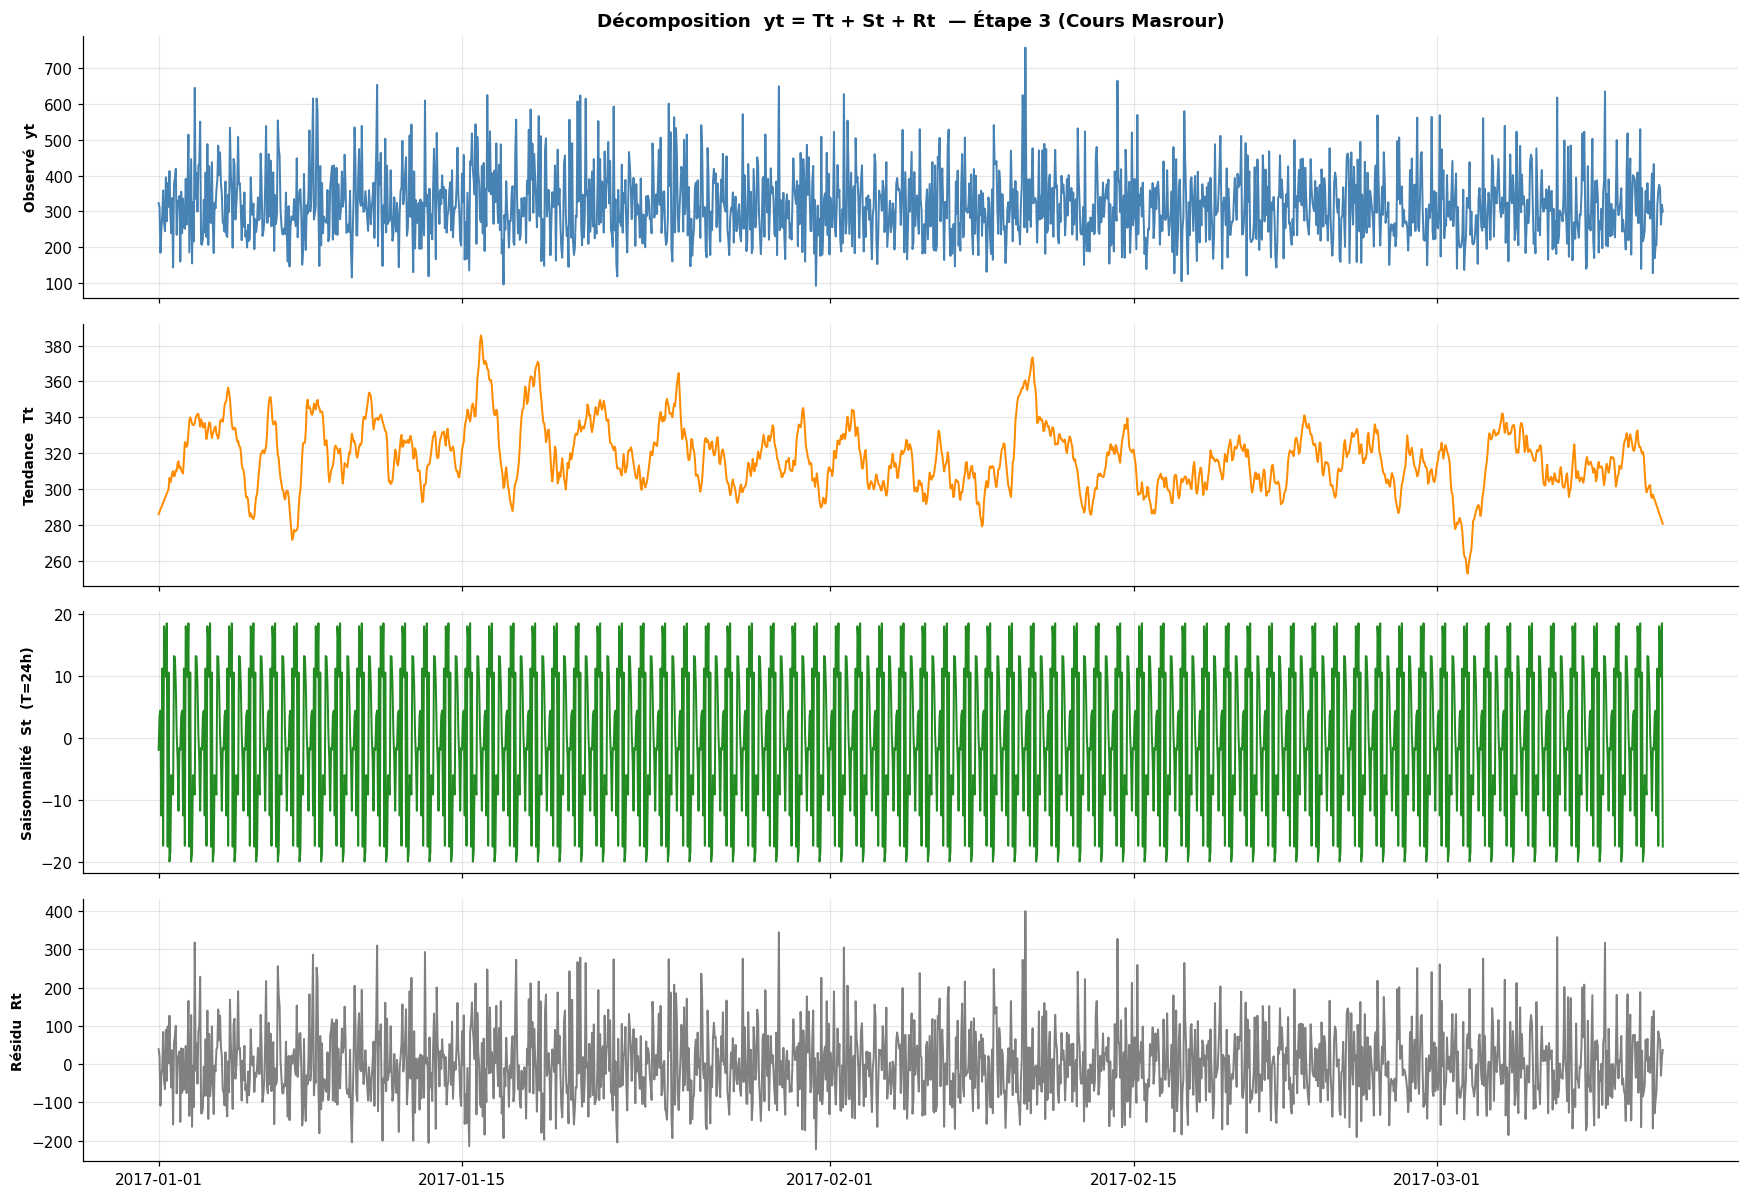

  Saisonnalité = 1.6% de la variance


In [6]:
serie_stat = serie.diff().dropna() if d_order == 1 else serie.copy()
if d_order == 1:
    adf2 = adfuller(serie_stat, autolag='AIC')
    print(f'  ADF après diff → p={adf2[1]:.6f}  [{"✅" if adf2[1]<0.05 else "❌"}]')

decomp = seasonal_decompose(serie, model='additive', period=24, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
for ax, (comp, title, col) in zip(axes, [
    (decomp.observed, 'Observé  yt', 'steelblue'),
    (decomp.trend,    'Tendance  Tt', 'darkorange'),
    (decomp.seasonal, 'Saisonnalité  St  (T=24h)', 'forestgreen'),
    (decomp.resid,    'Résidu  Rt', 'gray')]):
    ax.plot(comp, color=col, lw=1.3)
    ax.set_ylabel(title, fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_title('Décomposition  yt = Tt + St + Rt  — Étape 3 (Cours Masrour)',
                  fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('etape3_decomposition.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'  Saisonnalité = {decomp.seasonal.var()/decomp.observed.var()*100:.1f}% de la variance')


## 📊 Étape 4 — ACF / PACF → Identification p, d, q

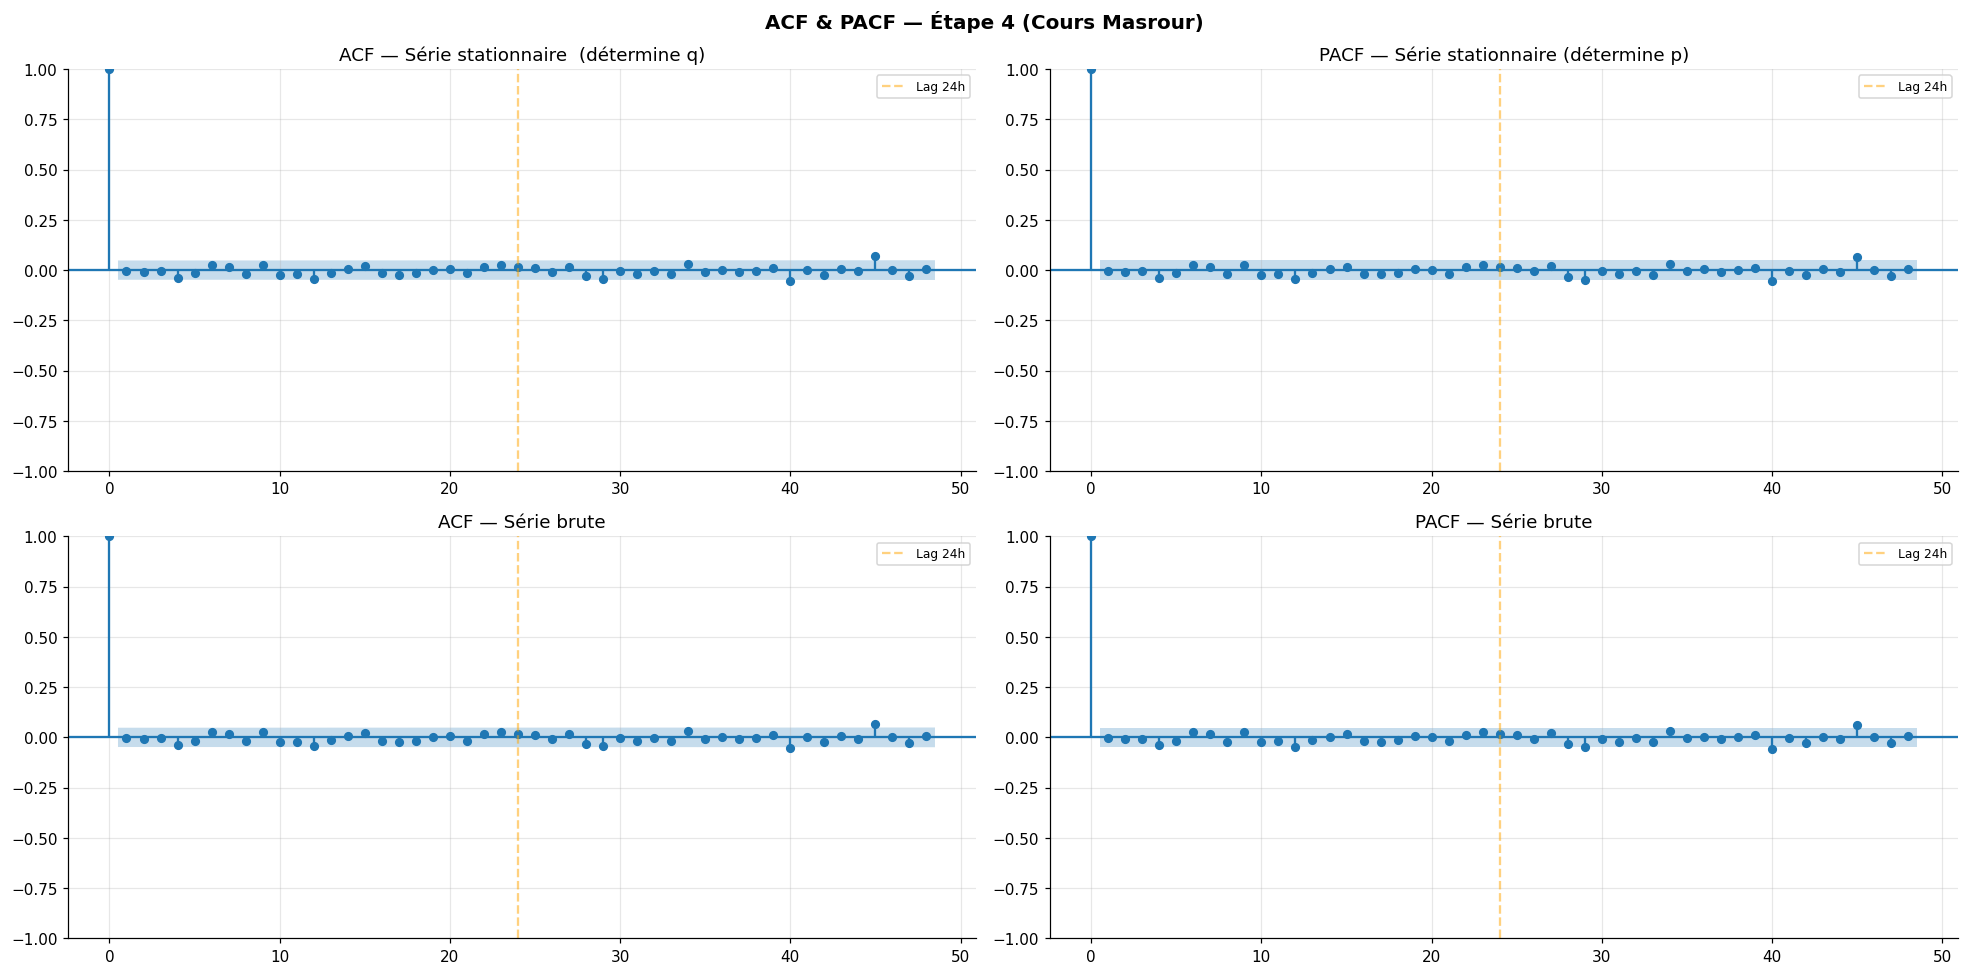

  Paramètres retenus : p=1  d=0  q=1  S=24


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 9))
plot_acf (serie_stat, lags=48, ax=axes[0,0], title='ACF — Série stationnaire  (détermine q)')
plot_pacf(serie_stat, lags=48, ax=axes[0,1], title='PACF — Série stationnaire (détermine p)', method='ywm')
plot_acf (serie,      lags=48, ax=axes[1,0], title='ACF — Série brute')
plot_pacf(serie,      lags=48, ax=axes[1,1], title='PACF — Série brute', method='ywm')
for ax in axes.flatten():
    ax.axvline(x=24, color='orange', ls='--', alpha=0.5, label='Lag 24h')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('ACF & PACF — Étape 4 (Cours Masrour)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('etape4_acf_pacf.png', dpi=110, bbox_inches='tight')
plt.show()

p_order, q_order, S_period = 1, 1, 24
print(f'  Paramètres retenus : p={p_order}  d={d_order}  q={q_order}  S={S_period}')


## 🔧 Étape 5 — Modèles ARIMA & SARIMAX

In [8]:
TEST_SIZE  = max(int(len(df) * 0.15), 24)
train_df   = df.iloc[:-TEST_SIZE]
test_df    = df.iloc[-TEST_SIZE:]
train_y, test_y   = train_df[TARGET], test_df[TARGET]
train_exog, test_exog = train_df[EXOG], test_df[EXOG]
print(f'  Train={len(train_y)}  |  Test={len(test_y)}')


  Train=1417  |  Test=250


In [9]:
# ARIMA
try:
    arima_fit = ARIMA(train_y, order=(p_order, d_order, q_order)).fit()
    pred_arima = arima_fit.get_forecast(steps=TEST_SIZE).predicted_mean
    store('ARIMA(1,d,1)', test_y.values, pred_arima.values, phase='Phase 1')
except Exception as e:
    print(f'  ARIMA : {e}')

# SARIMAX
try:
    sarimax_fit = SARIMAX(train_y, exog=train_exog,
                          order=(p_order, d_order, q_order),
                          seasonal_order=(1, 0, 1, S_period),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
    pred_sarimax = sarimax_fit.get_forecast(steps=TEST_SIZE, exog=test_exog).predicted_mean
    store('SARIMAX(1,d,1)x(1,0,1,24)', test_y.values, pred_sarimax.values, phase='Phase 1')
except Exception as e:
    print(f'  SARIMAX : {e}')

# Holt-Winters
try:
    hw_fit   = ExponentialSmoothing(train_y, trend='add', seasonal='add',
                                    seasonal_periods=S_period).fit(optimized=True)
    pred_hw  = hw_fit.forecast(TEST_SIZE)
    store('Holt-Winters', test_y.values, pred_hw.values, phase='Phase 1')
except Exception as e:
    print(f'  Holt-Winters : {e}')


  ARIMA(1,d,1)                     R²=-0.0069  MAE=73.8  RMSE=94.6  ❌ Faible
  SARIMAX(1,d,1)x(1,0,1,24)        R²=0.6547  MAE=44.7  RMSE=55.4  ✓ Bon
  Holt-Winters                     R²=-0.0380  MAE=73.8  RMSE=96.1  ❌ Faible


## 🔍 Étape 6 — Analyse des Résidus

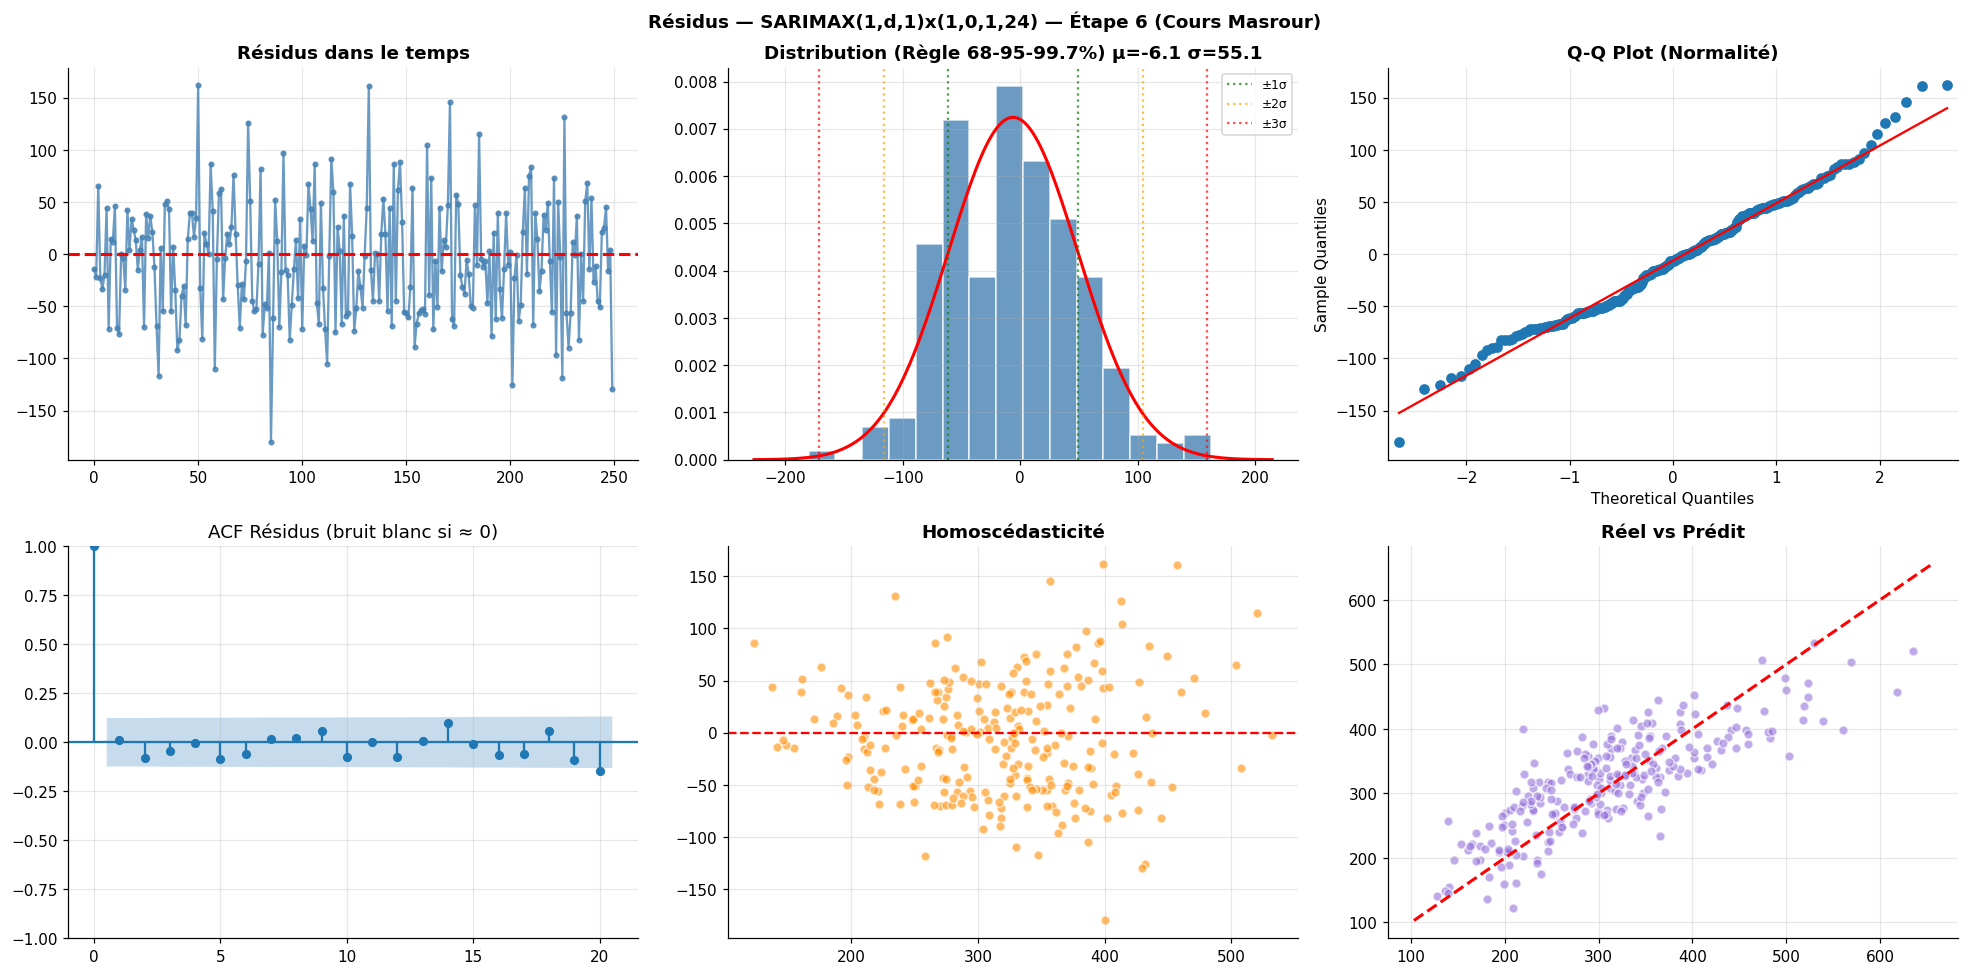


🔎 LJUNG-BOX :
    lb_stat  lb_pvalue
10   7.3133     0.6956
20  22.9814     0.2897

✅ Bruit Blanc (p>0.05)


In [10]:
# Résidus du meilleur modèle statistique
best_stat = max([k for k in RESULTS if RESULTS[k]['Phase']=='Phase 1'],
                key=lambda k: RESULTS[k]['R²'])
y_true_s, y_pred_s = PREDS[best_stat]
residuals = y_true_s - y_pred_s

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0,0].plot(residuals, color='steelblue', lw=1.5, marker='o', ms=3, alpha=0.8)
axes[0,0].axhline(0, color='red', ls='--', lw=2)
axes[0,0].set_title('Résidus dans le temps', fontweight='bold'); axes[0,0].grid(alpha=0.3)

mu_r, std_r = residuals.mean(), residuals.std()
axes[0,1].hist(residuals, bins=15, color='steelblue', edgecolor='white', alpha=0.8, density=True)
x_n = np.linspace(mu_r-4*std_r, mu_r+4*std_r, 200)
axes[0,1].plot(x_n, stats.norm.pdf(x_n, mu_r, std_r), 'r-', lw=2)
for k, col in [(1,'green'),(2,'orange'),(3,'red')]:
    axes[0,1].axvline(mu_r+k*std_r, color=col, ls=':', alpha=0.7, label=f'±{k}σ')
    axes[0,1].axvline(mu_r-k*std_r, color=col, ls=':', alpha=0.7)
axes[0,1].set_title(f'Distribution (Règle 68-95-99.7%) μ={mu_r:.1f} σ={std_r:.1f}', fontweight='bold')
axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

sm.qqplot(residuals, line='s', ax=axes[0,2])
axes[0,2].set_title('Q-Q Plot (Normalité)', fontweight='bold'); axes[0,2].grid(alpha=0.3)

plot_acf(residuals, lags=min(20, len(residuals)//2-1), ax=axes[1,0],
         title='ACF Résidus (bruit blanc si ≈ 0)')
axes[1,0].grid(alpha=0.3)

axes[1,1].scatter(y_pred_s, residuals, alpha=0.6, s=35, color='darkorange', edgecolors='white')
axes[1,1].axhline(0, color='red', ls='--')
axes[1,1].set_title('Homoscédasticité', fontweight='bold'); axes[1,1].grid(alpha=0.3)

axes[1,2].scatter(y_true_s, y_pred_s, alpha=0.6, s=35, color='mediumpurple', edgecolors='white')
lim = [min(y_true_s.min(),y_pred_s.min())-20, max(y_true_s.max(),y_pred_s.max())+20]
axes[1,2].plot(lim, lim, 'r--', lw=2)
axes[1,2].set_title('Réel vs Prédit', fontweight='bold'); axes[1,2].grid(alpha=0.3)

plt.suptitle(f'Résidus — {best_stat} — Étape 6 (Cours Masrour)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('etape6_residus.png', dpi=110, bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(residuals, lags=[10,20], return_df=True)
print('\n🔎 LJUNG-BOX :')
print(lb.round(4).to_string())
print('\n' + ('✅ Bruit Blanc (p>0.05)' if lb['lb_pvalue'].min()>0.05 else '⚠️ Autocorrélation résiduelle'))


## 🔮 Étape 7 — Prévision + Intervalles de Confiance

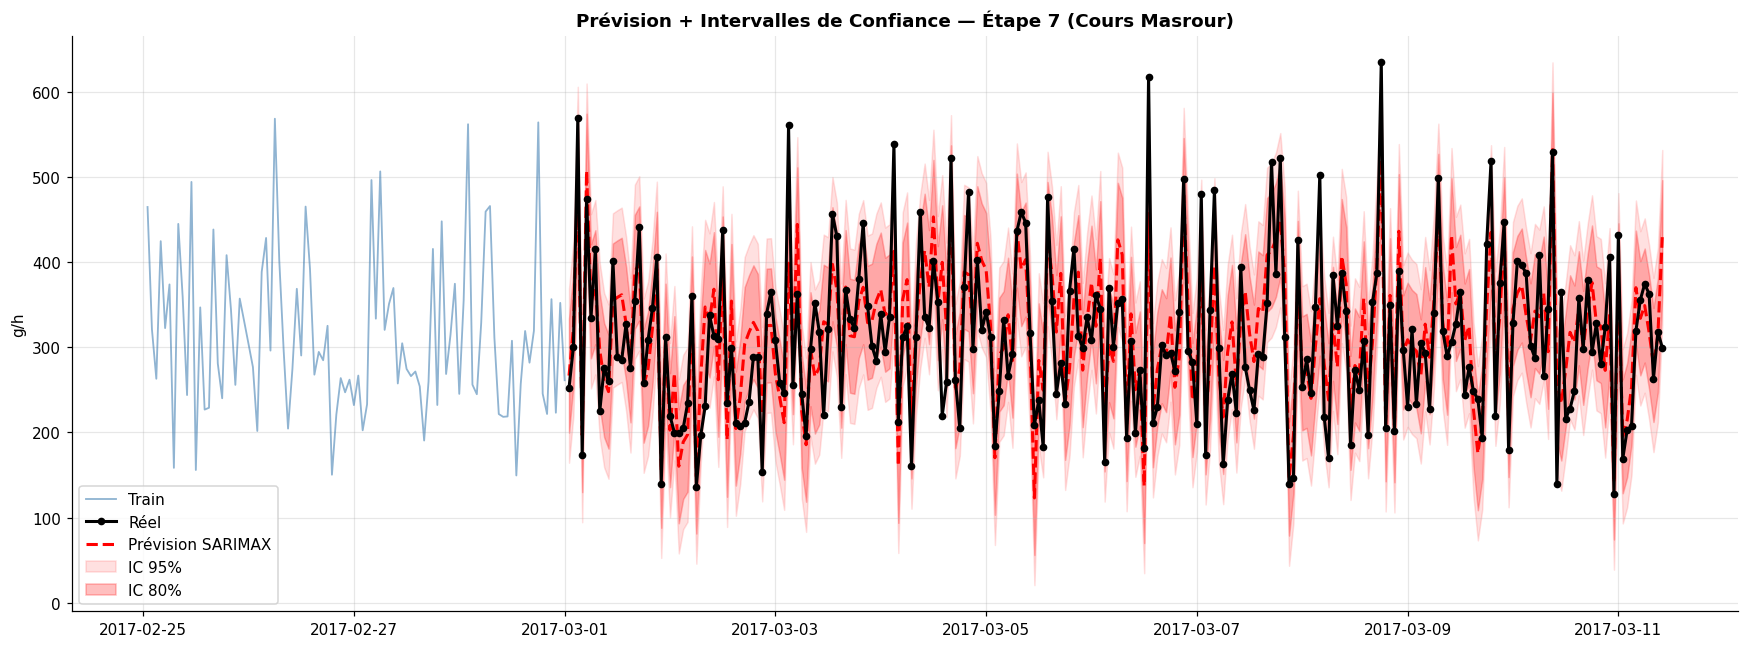

✅ Étape 7 complète

════════════════════════════════════════════════════════════
  PHASE 1 — RÉSULTATS STATISTIQUES
════════════════════════════════════════════════════════════
  ARIMA(1,d,1)                        R²=-0.0069  ❌ Faible
  SARIMAX(1,d,1)x(1,0,1,24)           R²=0.6547  ✓ Bon
  Holt-Winters                        R²=-0.0380  ❌ Faible


In [11]:
try:
    fc = sarimax_fit.get_forecast(steps=TEST_SIZE, exog=test_exog)
    pm = fc.predicted_mean
    ci80 = fc.conf_int(alpha=0.20)
    ci95 = fc.conf_int(alpha=0.05)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(train_y.iloc[-96:], color='steelblue', lw=1.2, alpha=0.6, label='Train')
    ax.plot(test_y, color='black', lw=2, marker='o', ms=4, label='Réel', zorder=5)
    ax.plot(test_y.index, pm, color='red', lw=2, ls='--', label='Prévision SARIMAX')
    ax.fill_between(test_y.index, ci95.iloc[:,0], ci95.iloc[:,1], alpha=0.12, color='red', label='IC 95%')
    ax.fill_between(test_y.index, ci80.iloc[:,0], ci80.iloc[:,1], alpha=0.25, color='red', label='IC 80%')
    ax.set_title('Prévision + Intervalles de Confiance — Étape 7 (Cours Masrour)',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('g/h'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('etape7_prevision_ic.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('✅ Étape 7 complète')
except Exception as e:
    print(f'IC : {e}')

print('\n' + '═'*60)
print('  PHASE 1 — RÉSULTATS STATISTIQUES')
print('═'*60)
for k,v in RESULTS.items():
    print(f'  {k:<35} R²={v["R²"]:.4f}  {v["Qualité"]}')


---
# 🧠 PHASE 2 — Deep Learning


## ⚙️ Preprocessing DL — MinMaxScaler + Séquences float32

In [12]:
# ══════════════════════════════════════════════════════════════
# ✅ FIX FLOAT32 — cast dès la source
#    → plus aucun tf.constant, plus aucun dtype=tf.float32 nécessaire
# ══════════════════════════════════════════════════════════════
scaler_X    = MinMaxScaler()
scaler_y_dl = MinMaxScaler()

data_scaled = scaler_X.fit_transform(
    df[ALL_VARS].values
).astype(np.float32)          # ← float32 ici, une seule fois

target_idx  = ALL_VARS.index(TARGET)
scaler_y_dl.fit(df[[TARGET]].values)

def build_seqs(data, t_idx, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, :])
        y.append(data[i, t_idx])
    return (np.array(X, dtype=np.float32),  # ← float32 garanti
            np.array(y, dtype=np.float32))

X_all, y_all = build_seqs(data_scaled, target_idx, SEQ_LEN)
N_FEAT = X_all.shape[2]

n       = len(X_all)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_all[:n_train],              y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],        y_all[n_train+n_val:]

y_test_orig = scaler_y_dl.inverse_transform(
    y_test.reshape(-1,1)
).flatten()

print('✅ Séquences créées')
print(f'   X shape : {X_all.shape}  (N × {SEQ_LEN} × {N_FEAT})')
print(f'   dtype   : {X_all.dtype}  ← float32 ✅')
print(f'   Train={len(y_train)}  Val={len(y_val)}  Test={len(y_test)}')

def cb(name):
    return [
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

def eval_dl(name, model, phase='Phase 2'):
    p_s = model.predict(X_test, verbose=0).flatten()
    y_p = scaler_y_dl.inverse_transform(p_s.reshape(-1,1)).flatten()
    store(name, y_test_orig, y_p, phase=phase)
    return y_p


✅ Séquences créées
   X shape : (1643, 24, 5)  (N × 24 × 5)
   dtype   : float32  ← float32 ✅
   Train=1150  Val=246  Test=247


### 🔵 ANN — Dense Feed-Forward

In [14]:
print('—'*55); print('  ANN (Dense Feed-Forward)'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

# ✅ Forcer la conversion en float32 (sécurité)
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

# 🔍 Diagnostic
print("X_train dtype :", X_train.dtype)
print("y_train dtype :", y_train.dtype)
print("X_val dtype   :", X_val.dtype)
print("y_val dtype   :", y_val.dtype)
print("X_train shape :", X_train.shape)

# Architecture
inp = Input(shape=(SEQ_LEN, N_FEAT))
x   = Flatten()(inp)
for u in [256, 128, 64]:
    x = Dense(u, activation='relu',
              kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
ann = Model(inp, Dense(1)(x), name='ANN')

# ✅ Compile avec objets (pas strings) — évite le bug Keras 3
ann.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()

# ✅ Entraînement SANS callbacks pour tester
h = ann.fit(X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS, batch_size=BATCH,
            callbacks=None,        # ⬅️ on retire les callbacks d'abord
            verbose=0)

HISTORIES['ANN'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={ann.count_params():,}')
eval_dl('ANN', ann)

———————————————————————————————————————————————————————
  ANN (Dense Feed-Forward)
———————————————————————————————————————————————————————
X_train dtype : float32
y_train dtype : float32
X_val dtype   : float32
y_val dtype   : float32
X_train shape : (1150, 24, 5)
  Entraîné en 44.7s | 150 epochs | params=73,985
  ANN                              R²=-0.2128  MAE=81.4  RMSE=102.8  ❌ Faible


array([323.84933, 328.5755 , 421.22702, 248.39424, 276.8754 , 292.86426,
       368.83325, 272.8995 , 364.15024, 288.60602, 319.21097, 222.35768,
       272.71844, 249.48468, 335.85834, 245.53764, 299.2441 , 247.76015,
       271.4614 , 297.9041 , 314.3621 , 287.41696, 299.14612, 258.6191 ,
       254.96123, 332.24756, 262.76474, 305.72775, 284.25345, 375.98114,
       400.26114, 283.6731 , 237.70082, 302.44778, 308.9778 , 450.1674 ,
       257.1197 , 292.94028, 449.0102 , 306.56216, 386.30292, 290.0185 ,
       342.16022, 284.2768 , 281.30933, 270.5337 , 341.5247 , 426.22775,
       255.89487, 289.19186, 299.99777, 320.45038, 289.59747, 316.87372,
       281.60397, 284.05212, 313.8759 , 204.04518, 253.21878, 318.1001 ,
       360.6549 , 331.9301 , 279.1494 , 348.47394, 296.02335, 332.1893 ,
       303.01395, 321.58853, 249.64714, 289.9904 , 225.49847, 306.36285,
       285.23526, 340.4938 , 308.94232, 308.65155, 291.3055 , 336.1662 ,
       301.90494, 316.14227, 320.0312 , 222.24127, 

### 🟢 LSTM — Long Short-Term Memory

In [16]:
print('—'*55); print('  LSTM'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

# ✅ Forcer la conversion en float32 (sécurité)
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

# Architecture
lstm_m = Sequential([
    Input(shape=(SEQ_LEN, N_FEAT)),
    LSTM(128, return_sequences=True,
         kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    LSTM(64, return_sequences=False,
         kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'), Dense(1)
], name='LSTM')

# ✅ Compile avec objets (pas strings) — évite le bug Keras 3
lstm_m.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()

# ✅ Entraînement SANS callbacks pour tester
h = lstm_m.fit(X_train, y_train,
               validation_data=(X_val, y_val),
               epochs=EPOCHS, batch_size=BATCH,
               callbacks=None,        # ⬅️ on retire les callbacks d'abord
               verbose=0)

HISTORIES['LSTM'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={lstm_m.count_params():,}')
eval_dl('LSTM', lstm_m)

———————————————————————————————————————————————————————
  LSTM
———————————————————————————————————————————————————————
  Entraîné en 200.7s | 150 epochs | params=120,897
  LSTM                             R²=-0.0949  MAE=77.9  RMSE=97.7  ❌ Faible


array([335.16068, 333.3432 , 239.5204 , 261.91998, 287.9943 , 302.91724,
       301.0493 , 299.20325, 296.20117, 317.94073, 300.2908 , 302.62793,
       308.37027, 303.285  , 298.84793, 301.12894, 330.52643, 324.06943,
       315.30304, 336.34415, 348.01123, 363.0325 , 329.1832 , 332.7103 ,
       322.66785, 322.8631 , 328.27277, 334.35617, 325.41476, 342.16708,
       338.01236, 335.8128 , 342.55966, 327.14474, 327.98938, 312.14944,
       326.31952, 326.77527, 335.515  , 354.95078, 370.1692 , 350.7466 ,
       354.88727, 356.72424, 348.44284, 347.99542, 357.15936, 409.9234 ,
       405.65152, 415.8708 , 334.18152, 285.41425, 300.4395 , 332.64142,
       404.3588 , 430.71448, 493.11722, 473.60925, 392.34653, 323.07324,
       324.0137 , 317.7695 , 318.12738, 315.07043, 312.65228, 316.2061 ,
       311.6732 , 308.2798 , 307.64685, 302.3393 , 299.20224, 293.0312 ,
       290.56253, 294.20688, 297.9186 , 301.74158, 302.05743, 298.08847,
       294.81003, 291.0247 , 294.48364, 292.48483, 

### 🔴 Bi-LSTM — Bidirectionnel

In [18]:
print('—'*55); print('  Bi-LSTM'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

# ✅ Forcer la conversion en float32 (sécurité)
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

# Architecture
bilstm = Sequential([
    Input(shape=(SEQ_LEN, N_FEAT)),
    Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=regularizers.l2(1e-4))),
    BatchNormalization(), Dropout(0.25),
    Bidirectional(LSTM(32,
                       kernel_regularizer=regularizers.l2(1e-4))),
    BatchNormalization(), Dropout(0.25),
    Dense(16, activation='relu'), Dense(1)
], name='BiLSTM')

# ✅ Compile avec objets (pas strings) — évite le bug Keras 3
bilstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()

# ✅ Entraînement SANS callbacks pour tester
h = bilstm.fit(X_train, y_train,
               validation_data=(X_val, y_val),
               epochs=EPOCHS, batch_size=BATCH,
               callbacks=None,        # ⬅️ on retire les callbacks d'abord
               verbose=0)

HISTORIES['Bi-LSTM'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={bilstm.count_params():,}')
eval_dl('Bi-LSTM', bilstm)

———————————————————————————————————————————————————————
  Bi-LSTM
———————————————————————————————————————————————————————
  Entraîné en 183.9s | 150 epochs | params=78,881


  Bi-LSTM                          R²=-0.2477  MAE=83.2  RMSE=104.3  ❌ Faible


array([252.13889, 308.13934, 214.56367, 264.62363, 299.33353, 324.3903 ,
       233.10199, 291.38968, 274.6144 , 300.50778, 315.70352, 301.7436 ,
       289.94275, 288.8478 , 292.33588, 300.30746, 276.63095, 292.52032,
       301.46127, 315.41415, 313.05505, 317.33344, 317.81775, 335.77066,
       344.5477 , 341.1107 , 354.59674, 351.0686 , 362.27322, 355.53082,
       357.20462, 344.52753, 342.38318, 321.17624, 291.66882, 301.56113,
       302.9524 , 330.7007 , 352.13113, 390.71826, 431.3295 , 435.94333,
       472.5413 , 470.26187, 465.04968, 433.1303 , 419.0028 , 368.4197 ,
       352.70712, 359.12476, 368.64478, 364.36447, 376.5391 , 365.92297,
       368.1418 , 365.27487, 357.30368, 309.44824, 256.80045, 224.74873,
       296.49677, 295.8913 , 292.73788, 292.27124, 279.73788, 275.7793 ,
       275.51096, 281.8893 , 283.18152, 277.8685 , 284.55145, 275.51096,
       275.51096, 297.84595, 277.3121 , 302.62234, 308.68576, 331.3175 ,
       379.55533, 309.89008, 295.83975, 293.8763 , 

### 🟡 GRU — Gated Recurrent Unit

In [20]:
print('—'*55); print('  GRU'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

gru_m = Sequential([
    Input(shape=(SEQ_LEN, N_FEAT)),
    GRU(128, return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    GRU(64, return_sequences=False,
        kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'), Dense(1)
], name='GRU')

gru_m.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()
h = gru_m.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=BATCH,
              callbacks=None,           # ⬅️ SANS callbacks
              verbose=0)
HISTORIES['GRU'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={gru_m.count_params():,}')
eval_dl('GRU', gru_m)

———————————————————————————————————————————————————————
  GRU
———————————————————————————————————————————————————————
  Entraîné en 199.8s | 150 epochs | params=91,969


  GRU                              R²=-0.0673  MAE=77.2  RMSE=96.5  ❌ Faible


array([326.8086 , 324.23837, 328.76196, 330.30655, 335.0623 , 340.10895,
       339.4657 , 337.36697, 332.01627, 329.10587, 325.76926, 324.9243 ,
       322.03613, 321.63724, 324.7419 , 335.34845, 332.28723, 331.9402 ,
       330.81778, 334.72845, 335.33887, 336.32562, 335.52148, 336.35202,
       336.01797, 336.8108 , 334.89304, 337.64188, 339.94778, 336.7864 ,
       332.65457, 332.57034, 338.8621 , 331.45956, 330.56406, 330.39087,
       337.26874, 341.80722, 344.60815, 347.16553, 357.7669 , 349.61435,
       356.41135, 348.54416, 353.17035, 356.9399 , 361.5257 , 355.4568 ,
       346.76346, 349.12198, 337.3594 , 338.30377, 342.73303, 336.26993,
       338.58682, 341.3842 , 341.8393 , 348.30304, 347.11963, 353.73563,
       356.2522 , 353.10776, 346.51855, 343.59946, 346.4743 , 348.44473,
       341.59778, 344.1645 , 344.39185, 346.128  , 342.94073, 336.22293,
       338.03122, 339.22787, 340.47125, 337.4533 , 338.11612, 340.09305,
       338.29834, 333.88013, 332.77853, 331.38226, 

### 🟣 CNN-LSTM — Extraction Locale + Mémoire

In [26]:
print('—'*55); print('  CNN-LSTM'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

cnn_lstm = Sequential([
    Input(shape=(SEQ_LEN, N_FEAT)),
    Conv1D(64,  3, activation='relu', padding='causal'),
    BatchNormalization(),
    Conv1D(128, 3, activation='relu', padding='causal'),
    BatchNormalization(),
    MaxPooling1D(2), Dropout(0.2),
    LSTM(64, kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'), Dense(1)
], name='CNN_LSTM')

cnn_lstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()
h = cnn_lstm.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH,
                 callbacks=None,         # ⬅️ SANS callbacks
                 verbose=0)
HISTORIES['CNN-LSTM'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={cnn_lstm.count_params():,}')
eval_dl('CNN-LSTM', cnn_lstm)

———————————————————————————————————————————————————————
  CNN-LSTM
———————————————————————————————————————————————————————
  Entraîné en 84.3s | 150 epochs | params=78,273
  CNN-LSTM                         R²=-0.4767  MAE=87.0  RMSE=113.5  ❌ Faible


array([332.6113 , 323.0406 , 316.4913 , 241.88986, 254.82254, 285.77847,
       298.34375, 229.32793, 294.24475, 275.617  , 210.91655, 312.59158,
       247.94615, 251.62888, 246.77415, 252.39987, 291.4178 , 307.04477,
       292.35345, 281.5993 , 300.04977, 301.94638, 297.2589 , 273.03455,
       358.08533, 390.12466, 285.97867, 256.1686 , 341.47412, 326.6844 ,
       316.7883 , 303.09106,  96.87236, 227.42679, 246.8923 , 363.95386,
       296.95474, 259.35803, 252.99655, 254.91502, 294.23148, 293.92603,
       309.1396 , 321.50558, 267.79678, 205.62369, 303.34073, 334.43307,
       270.30002, 249.67552, 367.78415, 351.2167 , 344.3737 , 338.08035,
       276.97336, 268.8699 , 278.4174 , 284.67725, 326.4273 , 309.45157,
       283.2482 , 320.99228, 324.84546, 365.34415, 345.124  , 330.37692,
       229.29077, 228.67354, 209.57193, 231.96236, 226.52112, 222.36954,
       226.22885, 234.46622, 224.01141, 176.08052, 322.82993, 267.3551 ,
       259.43976, 289.24362, 233.75636, 259.84055, 

### ⭐ Attention-LSTM — Multi-Head Self-Attention

In [30]:
print('—'*55); print('  Attention-LSTM (Multi-Head)'); print('—'*55)

import numpy as np
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)

seq_in = Input(shape=(SEQ_LEN, N_FEAT))
x      = LSTM(128, return_sequences=True,
              kernel_regularizer=regularizers.l2(1e-4))(seq_in)
x      = BatchNormalization()(x); x = Dropout(0.2)(x)
attn   = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
x      = LayerNormalization()(Add()([x, attn]))
pooled = GlobalAveragePooling1D()(x)
x      = Dense(64, activation='relu',
               kernel_regularizer=regularizers.l2(1e-4))(pooled)
x      = BatchNormalization()(x); x = Dropout(0.3)(x)
attn_lstm = Model(seq_in, Dense(1)(x), name='Attention_LSTM')

attn_lstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

t0 = time.time()
h = attn_lstm.fit(X_train, y_train,
                  validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH,
                  callbacks=None,         # ⬅️ SANS callbacks
                  verbose=0)
HISTORIES['Attention-LSTM'] = h
print(f'  Entraîné en {time.time()-t0:.1f}s | {len(h.epoch)} epochs | params={attn_lstm.count_params():,}')
eval_dl('Attention-LSTM', attn_lstm)

———————————————————————————————————————————————————————
  Attention-LSTM (Multi-Head)
———————————————————————————————————————————————————————
  Entraîné en 263.5s | 150 epochs | params=144,001
  Attention-LSTM                   R²=-0.2767  MAE=86.6  RMSE=105.5  ❌ Faible


array([363.31946, 372.52887, 377.1796 , 377.38666, 383.9663 , 388.8991 ,
       364.6044 , 355.5936 , 349.33826, 332.04837, 341.53482, 328.44873,
       313.51114, 312.26166, 316.11746, 329.34946, 324.1545 , 332.1701 ,
       335.2484 , 344.9215 , 342.85455, 354.74042, 341.63635, 351.32535,
       354.415  , 358.8893 , 368.84692, 376.78412, 374.67953, 365.99408,
       360.9522 , 371.02612, 366.09558, 359.32358, 349.53043, 346.49042,
       362.53836, 373.76047, 381.61212, 386.77505, 389.17792, 369.8625 ,
       358.7677 , 363.49603, 364.1055 , 368.66885, 374.216  , 367.1244 ,
       365.55713, 360.38147, 343.72922, 338.3062 , 351.26227, 351.37228,
       358.808  , 364.34705, 227.41835, 343.84445, 350.9225 , 367.221  ,
       360.87994, 362.50183, 349.6801 , 350.18582, 361.78558, 373.9294 ,
       371.35245, 377.97626, 388.4877 , 353.15833, 341.60168, 328.05307,
       331.3139 , 333.7649 , 342.37775, 346.8188 , 353.68024, 365.9792 ,
       363.8689 , 351.94983, 351.98285, 335.69373, 

---
# ⚡ PHASE 3 — XGBoost avec Feature Engineering


In [21]:
def build_features_xgb(df_in, target, exog_vars):
    df_f = df_in.copy()
    for lag in [1,2,3,6,12,24]:
        df_f[f'y_lag{lag}'] = df_f[target].shift(lag)
    for var in exog_vars:
        s = var.split('_')[0]
        df_f[f'{s}_lag1'] = df_f[var].shift(1)
        df_f[f'{s}_lag3'] = df_f[var].shift(3)
    for w in [3, 6, 12]:
        df_f[f'y_rmean{w}'] = df_f[target].shift(1).rolling(w).mean()
        df_f[f'y_rstd{w}']  = df_f[target].shift(1).rolling(w).std()
    df_f['hour']     = df_f.index.hour
    df_f['hour_sin'] = np.sin(2*np.pi*df_f['hour']/24)
    df_f['hour_cos'] = np.cos(2*np.pi*df_f['hour']/24)
    df_f['dow_sin']  = np.sin(2*np.pi*df_f.index.dayofweek/7)
    df_f['dow_cos']  = np.cos(2*np.pi*df_f.index.dayofweek/7)
    df_f['HVAC_x_T'] = df_f['Consommation_HVAC_kWh'] * df_f['Temperature_C']
    df_f['H_x_T']    = df_f['Humidite_Relative_%']    * df_f['Temperature_C']
    df_f['dHVAC']    = df_f['Consommation_HVAC_kWh'].diff(1)
    return df_f.dropna()

df_xgb    = build_features_xgb(df, TARGET, EXOG)
feat_cols = [c for c in df_xgb.columns if c != TARGET]
X_xgb, y_xgb = df_xgb[feat_cols].values, df_xgb[TARGET].values

ts_xgb  = max(int(len(X_xgb)*0.15), 24)
sc_xgb  = StandardScaler()
Xtr_xgb = sc_xgb.fit_transform(X_xgb[:-ts_xgb])
Xte_xgb = sc_xgb.transform(X_xgb[-ts_xgb:])
ytr_xgb, yte_xgb = y_xgb[:-ts_xgb], y_xgb[-ts_xgb:]

print(f'✅ Features XGBoost : {len(feat_cols)}  |  Train={len(ytr_xgb)}  Test={len(yte_xgb)}')


✅ Features XGBoost : 32  |  Train=1397  Test=246


In [23]:
param_grid = {
    'n_estimators'    : [300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.03, 0.05, 0.10],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
tscv = TimeSeriesSplit(n_splits=5)
gs = GridSearchCV(xgb.XGBRegressor(random_state=42, verbosity=0),
                  param_grid, scoring='r2', cv=tscv, n_jobs=-1, verbose=0)
print('  ⏳ GridSearchCV...')
gs.fit(Xtr_xgb, ytr_xgb)
print(f'  Meilleurs params : {gs.best_params_}')
print(f'  R² CV moyen      : {gs.best_score_:.4f}')
store('XGBoost (optimisé)', yte_xgb, gs.best_estimator_.predict(Xte_xgb), phase='Phase 3')


  ⏳ GridSearchCV...
  Meilleurs params : {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
  R² CV moyen      : 0.8518
  XGBoost (optimisé)               R²=0.8401  MAE=29.7  RMSE=37.3  ✅ Excellent


0.8401073322569377

---
# 📊 PHASE 4 — Comparaison Finale


In [24]:
df_final = pd.DataFrame(RESULTS).T.reset_index().rename(columns={'index':'Modèle'})
df_final[['R²','MAE','RMSE','MAPE']] = df_final[['R²','MAE','RMSE','MAPE']].astype(float).round(4)
df_final = df_final.sort_values('R²', ascending=False).reset_index(drop=True)
df_final.insert(0, 'Rang', range(1, len(df_final)+1))

print('═'*90)
print('  TABLEAU COMPARATIF FINAL — Phase 1 (Masrour) + Phase 2 (DL) + Phase 3 (XGBoost)')
print('═'*90)
print(df_final[['Rang','Phase','Modèle','R²','MAE','RMSE','MAPE','Qualité']].to_string(index=False))

for phase, label in [('Phase 1','Cours Masrour'),('Phase 2','Deep Learning'),('Phase 3','XGBoost')]:
    s = df_final[df_final['Phase']==phase]
    if len(s):
        b = s.iloc[0]
        print(f'\n  Meilleur {label} : {b["Modèle"]:<35} R²={b["R²"]:.4f}  {b["Qualité"]}')

ob = df_final.iloc[0]
print(f'\n🏆 VAINQUEUR ABSOLU : {ob["Modèle"]}  (R²={ob["R²"]:.4f})')


══════════════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF FINAL — Phase 1 (Masrour) + Phase 2 (DL) + Phase 3 (XGBoost)
══════════════════════════════════════════════════════════════════════════════════════════
 Rang   Phase                    Modèle      R²     MAE     RMSE    MAPE     Qualité
    1 Phase 3        XGBoost (optimisé)  0.8401 29.7260  37.2511 10.1631 ✅ Excellent
    2 Phase 1 SARIMAX(1,d,1)x(1,0,1,24)  0.6547 44.7246  55.4206 15.4333       ✓ Bon
    3 Phase 1              ARIMA(1,d,1) -0.0069 73.8136  94.6397 27.4553    ❌ Faible
    4 Phase 1              Holt-Winters -0.0380 73.7880  96.0893 26.7110    ❌ Faible
    5 Phase 2                       GRU -0.0673 77.1784  96.4677 29.9999    ❌ Faible
    6 Phase 2                      LSTM -0.0949 77.8510  97.7037 28.7696    ❌ Faible
    7 Phase 2                       ANN -0.2128 81.3745 102.8321 28.5696    ❌ Faible
    8 Phase 2                   Bi-LSTM -0.2477 83.2453 

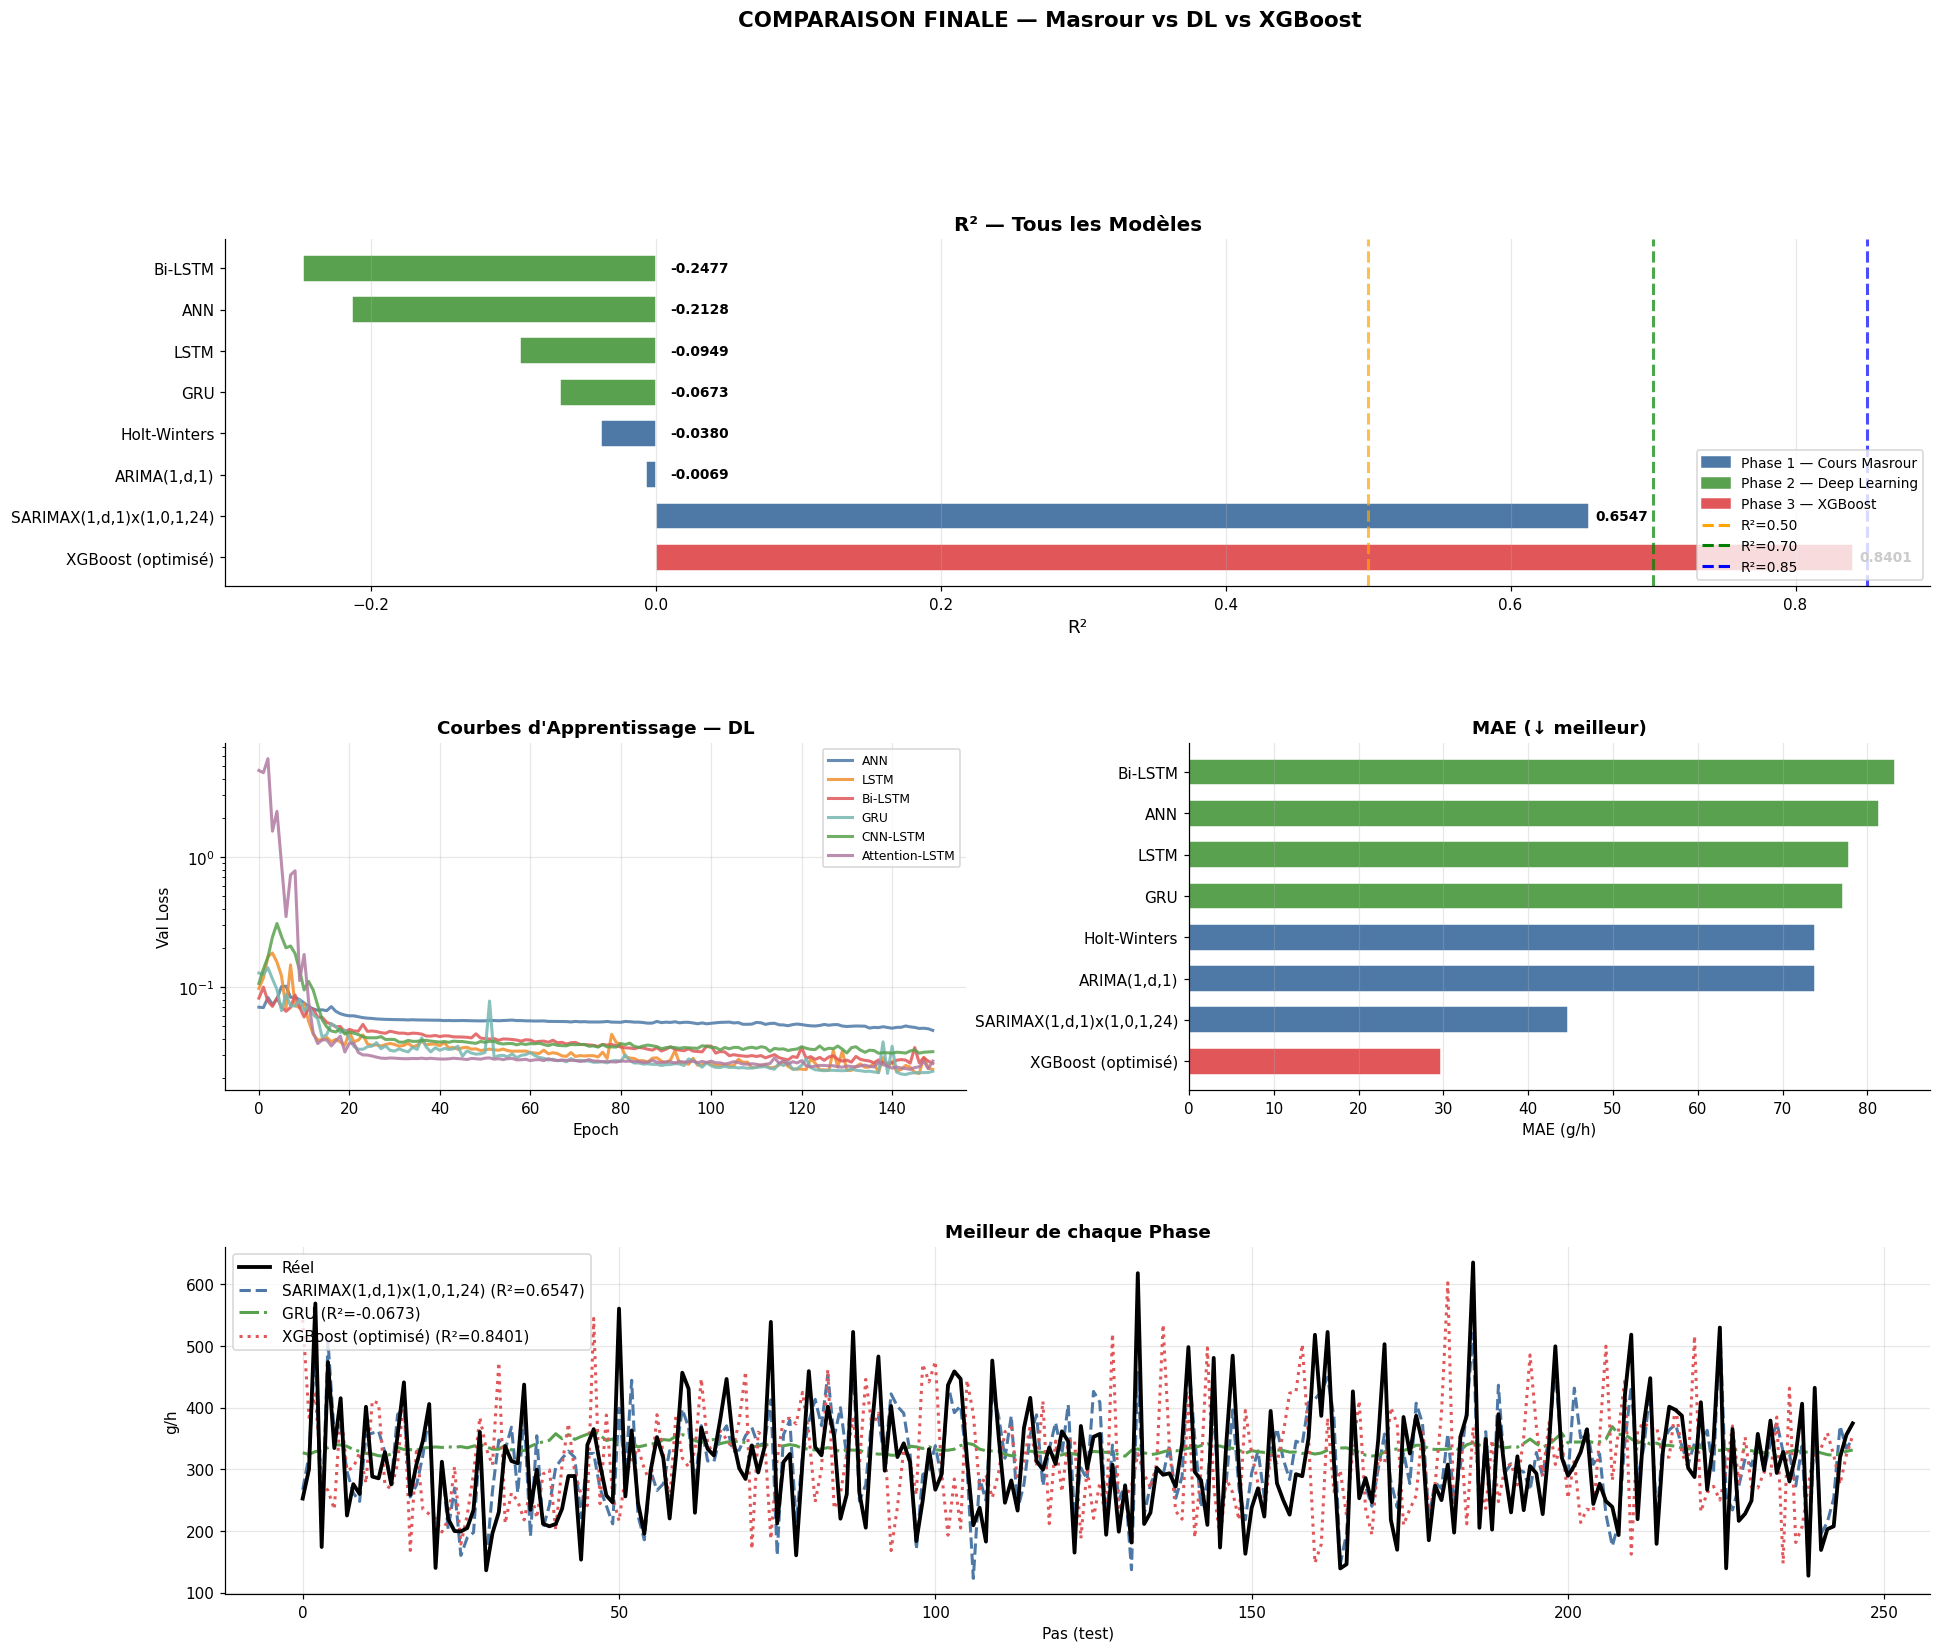

✅ Comparaison finale sauvegardée


In [32]:
from matplotlib.patches import Patch

phase_colors = {'Phase 1':'#4e79a7','Phase 2':'#59a14f','Phase 3':'#e15759'}
df_final = df_final.reset_index(drop=True)  # ✅ sécurise l'indexation
model_col = [phase_colors.get(df_final.loc[i,'Phase'],'#888') for i in range(len(df_final))]

fig = plt.figure(figsize=(20, 16))
gs_fig = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1) Barplot R²
ax1 = fig.add_subplot(gs_fig[0, :])
bars = ax1.barh(df_final['Modèle'], df_final['R²'].astype(float),
                color=model_col, edgecolor='white', height=0.65)
ax1.axvline(0.5,  color='orange', ls='--', alpha=0.7, lw=2)
ax1.axvline(0.7,  color='green',  ls='--', alpha=0.7, lw=2)
ax1.axvline(0.85, color='blue',   ls='--', alpha=0.7, lw=2)
for bar, v in zip(bars, df_final['R²'].astype(float)):
    ax1.text(max(v + 0.005, 0.01), bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
ax1.legend(handles=[
    Patch(color='#4e79a7', label='Phase 1 — Cours Masrour'),
    Patch(color='#59a14f', label='Phase 2 — Deep Learning'),
    Patch(color='#e15759', label='Phase 3 — XGBoost'),
    plt.Line2D([0],[0], color='orange', ls='--', lw=2, label='R²=0.50'),
    plt.Line2D([0],[0], color='green',  ls='--', lw=2, label='R²=0.70'),
    plt.Line2D([0],[0], color='blue',   ls='--', lw=2, label='R²=0.85'),
], fontsize=9, loc='lower right')
ax1.set_xlabel('R²', fontsize=12)
ax1.set_title('R² — Tous les Modèles', fontweight='bold', fontsize=13)
ax1.grid(alpha=0.3, axis='x')

# 2) Courbes d'apprentissage
dl_colors = {'ANN':'#4e79a7','LSTM':'#f28e2b','Bi-LSTM':'#e15759',
             'GRU':'#76b7b2','CNN-LSTM':'#59a14f','Attention-LSTM':'#b07aa1'}
ax2 = fig.add_subplot(gs_fig[1, 0])
for name, hist in HISTORIES.items():
    ax2.plot(hist.history['val_loss'], color=dl_colors.get(name, 'gray'),
             lw=2, label=name, alpha=0.85)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val Loss')
ax2.set_title("Courbes d'Apprentissage — DL", fontweight='bold')   # ✅ corrigé
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_yscale('log')

# 3) MAE
ax3 = fig.add_subplot(gs_fig[1, 1])
ax3.barh(df_final['Modèle'], df_final['MAE'].astype(float),
         color=model_col, edgecolor='white', height=0.65)
ax3.set_xlabel('MAE (g/h)')
ax3.set_title('MAE (↓ meilleur)', fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

# 4) Prédictions : meilleur de chaque phase
ax4 = fig.add_subplot(gs_fig[2, :])
best_p1 = df_final[df_final['Phase']=='Phase 1'].iloc[0]['Modèle']
best_p2 = df_final[df_final['Phase']=='Phase 2'].iloc[0]['Modèle']
best_p3 = df_final[df_final['Phase']=='Phase 3'].iloc[0]['Modèle']
min_len = min(len(PREDS[best_p1][0]), len(PREDS[best_p2][0]), len(PREDS[best_p3][0]))
ax4.plot(range(min_len), PREDS[best_p1][0][:min_len],
         color='black', lw=2.5, label='Réel', zorder=6)
for name, col, ls in [(best_p1,'#4e79a7','--'),
                      (best_p2,'#59a14f','-.'),
                      (best_p3,'#e15759',':')]:
    yp = PREDS[name][1][:min_len]
    ax4.plot(range(min_len), yp, color=col, lw=2, ls=ls,
             label=f'{name} (R²={RESULTS[name]["R²"]:.4f})')
ax4.set_xlabel('Pas (test)')
ax4.set_ylabel('g/h')
ax4.set_title('Meilleur de chaque Phase', fontweight='bold', fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.suptitle('COMPARAISON FINALE — Masrour vs DL vs XGBoost',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('comparaison_finale.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Comparaison finale sauvegardée')

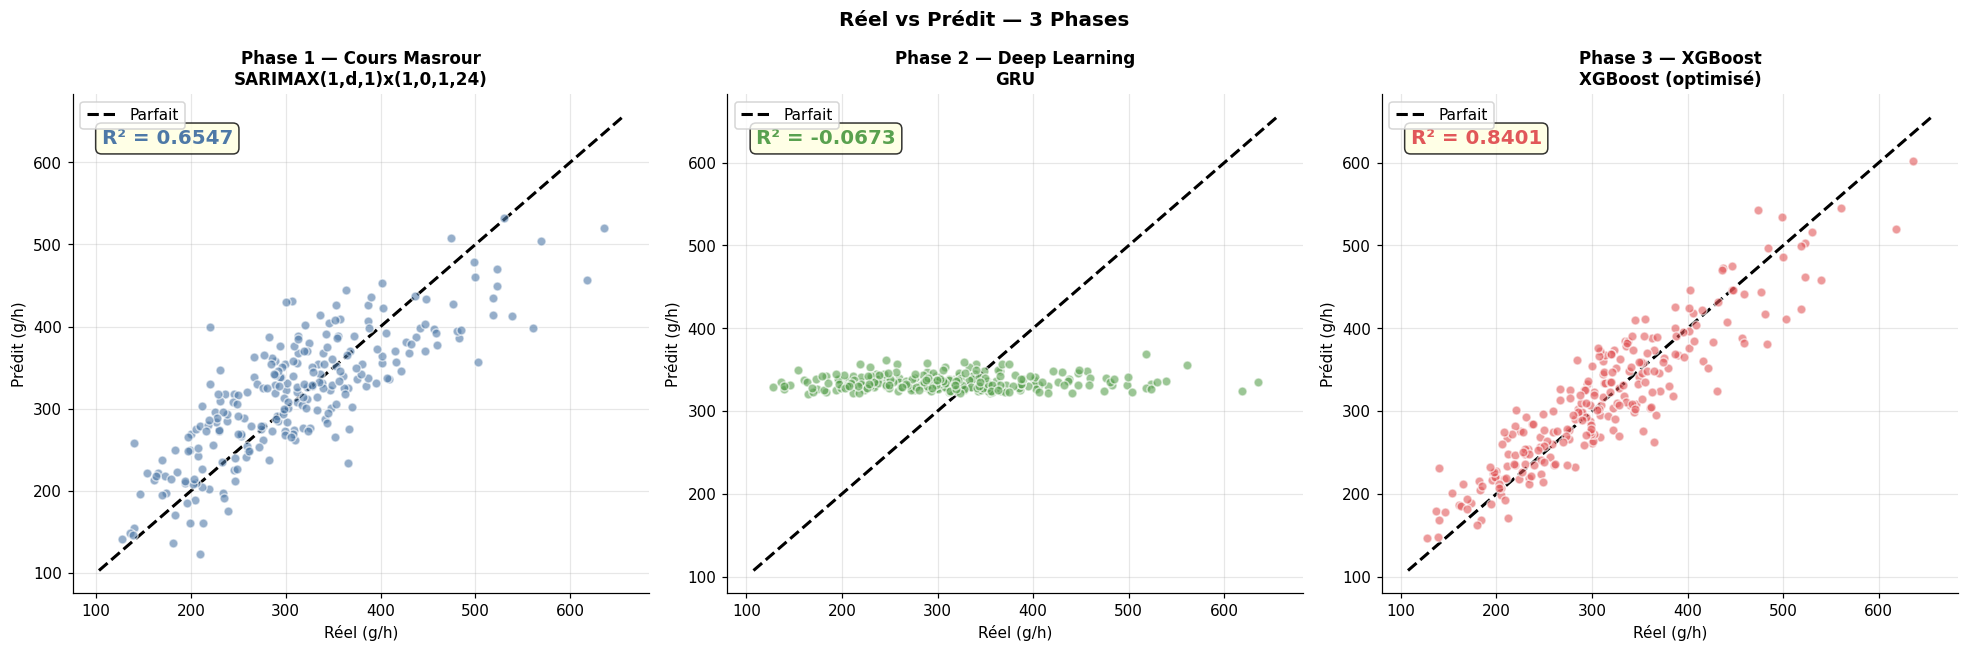

In [33]:
# ── Scatter 3 phases ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, col, title) in zip(axes, [
    (best_p1,'#4e79a7','Phase 1 — Cours Masrour'),
    (best_p2,'#59a14f','Phase 2 — Deep Learning'),
    (best_p3,'#e15759','Phase 3 — XGBoost')]):
    yt, yp = PREDS[name]
    ml = min(len(yt), len(yp))
    yt, yp = yt[:ml], yp[:ml]
    ax.scatter(yt, yp, alpha=0.6, s=35, c=col, edgecolors='white', zorder=3)
    lim = [min(yt.min(),yp.min())-20, max(yt.max(),yp.max())+20]
    ax.plot(lim, lim, 'k--', lw=2, label='Parfait')
    ax.set_xlabel('Réel (g/h)'); ax.set_ylabel('Prédit (g/h)')
    ax.set_title(f'{title}\n{name}', fontweight='bold', fontsize=11)
    ax.text(0.05, 0.90, f'R² = {RESULTS[name]["R²"]:.4f}', transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=col,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Réel vs Prédit — 3 Phases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_3phases.png', dpi=110, bbox_inches='tight')
plt.show()


In [34]:
# ── Checklist Masrour & synthèse finale ──────────────────────────
print('''
╔═════════════════════════════════════════════════════════════════════╗
║  CHECKLIST FINALE — COURS PR. MASROUR (2024-2025)                  ║
╠═════════════════════════════════════════════════════════════════════╣
║  ✅ Données nettoyées et sans valeurs manquantes                    ║
║  ✅ Étape 1 — Visualisation                                         ║
║  ✅ Étape 2 — Tests ADF + KPSS                                      ║
║  ✅ Étape 3 — Décomposition STL  yt = Tt + St + Rt                  ║
║  ✅ Étape 4 — ACF/PACF → p, d, q                                    ║
║  ✅ Étape 5 — ARIMA + SARIMAX + Holt-Winters                        ║
║  ✅ Étape 6 — Résidus (Ljung-Box + règle 3σ)                        ║
║  ✅ Étape 7 — Prévision + IC 80% et 95%                             ║
║  ✅ Phase 2 — ANN · LSTM · Bi-LSTM · GRU · CNN-LSTM · Attn-LSTM    ║
║  ✅ Phase 3 — XGBoost (GridSearchCV + TimeSeriesSplit)              ║
║  ✅ Phase 4 — Comparaison finale multi-phases                       ║
╚═════════════════════════════════════════════════════════════════════╝
''')
ob = df_final.iloc[0]
print(f'🏆 VAINQUEUR : {ob["Modèle"]}  R²={ob["R²"]:.4f}  {ob["Qualité"]}')

try:
    with pd.ExcelWriter('resultats_complets_hvac.xlsx', engine='openpyxl') as w:
        df_final.to_excel(w, sheet_name='Comparaison_Finale', index=False)
        min_l = min(len(v[0]) for v in PREDS.values())
        pd.DataFrame({'Réel': list(PREDS.values())[0][0][:min_l],
                      **{f'Pred_{k.replace(" ","_")}': v[1][:min_l]
                         for k,v in PREDS.items()}
                     }).to_excel(w, sheet_name='Predictions', index=False)
    print('✅ Export : resultats_complets_hvac.xlsx')
except Exception as e:
    print(f'Export : {e}')



╔═════════════════════════════════════════════════════════════════════╗
║  CHECKLIST FINALE — COURS PR. MASROUR (2024-2025)                  ║
╠═════════════════════════════════════════════════════════════════════╣
║  ✅ Données nettoyées et sans valeurs manquantes                    ║
║  ✅ Étape 1 — Visualisation                                         ║
║  ✅ Étape 2 — Tests ADF + KPSS                                      ║
║  ✅ Étape 3 — Décomposition STL  yt = Tt + St + Rt                  ║
║  ✅ Étape 4 — ACF/PACF → p, d, q                                    ║
║  ✅ Étape 5 — ARIMA + SARIMAX + Holt-Winters                        ║
║  ✅ Étape 6 — Résidus (Ljung-Box + règle 3σ)                        ║
║  ✅ Étape 7 — Prévision + IC 80% et 95%                             ║
║  ✅ Phase 2 — ANN · LSTM · Bi-LSTM · GRU · CNN-LSTM · Attn-LSTM    ║
║  ✅ Phase 3 — XGBoost (GridSearchCV + TimeSeriesSplit)              ║
║  ✅ Phase 4 — Comparaison finale multi-phases                       ║
╚═══